In [29]:
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import numpy as np

In [30]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0  67 232  39   0   0   0   0   0]
 [  0   0   0   0  62  81   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 120 180  39   0   0   0   0   0]
 [  0   0   0   0 126 163   0   0   0   0   0   0   0   0   0   0   0   0
    0   2 153 210  40   0   0   0   0   0]
 [  0   0   0   0 220 163   0   0   0   0   0   0   0   0   0   

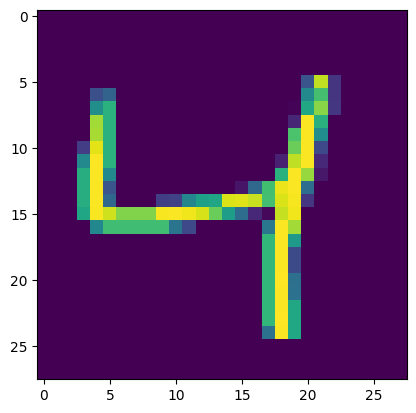

In [31]:
print(x_train[2])
plt.imshow(x_train[2])

In [32]:
x_train.shape

(60000, 28, 28)

In [33]:
y_train.shape

(60000,)

In [34]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

In [35]:
# Model
model = keras.Sequential([

    # 2D image → 1D
    keras.layers.Flatten(input_shape=(28,28)),

    # Hidden layer
    keras.layers.Dense(256, activation='relu'),

    # Output layer
    keras.layers.Dense(10, activation='softmax')

])

d:\Ostad\AI with Robotics\TensorFlow practice\env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
# Train
model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9349 - loss: 0.2272
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9717 - loss: 0.0947
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9810 - loss: 0.0612
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9866 - loss: 0.0434
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0322
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9919 - loss: 0.0251
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9936 - loss: 0.0199
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9952 - loss: 0.0148
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9955 - loss: 0.0134
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.0122


In [38]:
# Test
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9796 - loss: 0.0926
Accuracy: 0.9796000123023987


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction Probabilities:
[[1.0967329e-10 9.9997926e-01 2.7722876e-07 5.5360817e-07 6.8793992e-07
  2.1813426e-14 3.6116918e-11 1.8984587e-05 2.5822681e-07 3.1947960e-13]]
Predicted Digit: 1
Real Digit: 1


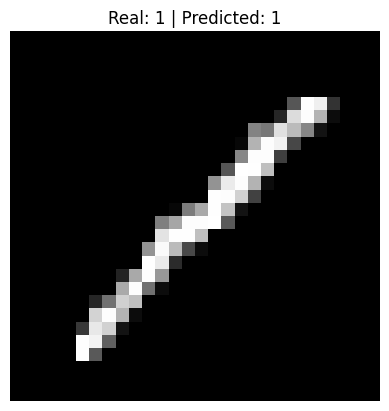

In [39]:
# Random image select
index = np.random.randint(0, len(x_test))

# Image
image = x_test[index]

# Real label
real_label = y_test[index]

# Prediction
prediction = model.predict(np.array([image]))

# Predicted digit
predicted_label = np.argmax(prediction)

# Show image
plt.imshow(image, cmap='gray')
plt.title(f"Real: {real_label} | Predicted: {predicted_label}")
plt.axis('off')

print("Prediction Probabilities:")
print(prediction)

print("Predicted Digit:", predicted_label)
print("Real Digit:", real_label)

plt.show()